<a href="https://colab.research.google.com/github/jmora420-hue/Ciencia_de_datos/blob/main/Limpieza_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Limpieza de datos

#AGENDA
1. cargar librerias
2. cargar dataset
3. revisar info
4. gestionar datos faltantes(eliminar, reemplazar por promedio)
5. Arreglar formato fechas
7. Convertir sold units a números, etc, ect

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/messy_sales.xlsx")
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32,USD 858,########,0.1
1,2024-01-30,north,Tablet,Electronics,72,833.83,########,15 percent
2,2024-02-13,EAST,laptop,ELEC,NaN,489.12,NaN,0.08
3,2024-04-28,West,Laptop,gadget,thirty,733.46,########,0.1
4,2024-02-18,EAST,Phone,ELEC,47,USD 373,40920,0.1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               200 non-null    datetime64[ns]
 1   Region             200 non-null    object        
 2   Product            200 non-null    object        
 3   Category           200 non-null    object        
 4   Units Sold         196 non-null    object        
 5   Unit Price         200 non-null    object        
 6   Total Sales        197 non-null    object        
 7   Profit Margin (%)  200 non-null    object        
dtypes: datetime64[ns](1), object(7)
memory usage: 12.6+ KB


In [4]:
df.isnull().sum()

,0
Date,0
Region,0
Product,0
Category,0
Units Sold,4
Unit Price,0
Total Sales,3
Profit Margin (%),0


aseguraos que los numeros son numeros


In [5]:
df['Units Sold']=pd.to_numeric(df['Units Sold'],errors='coerce')
df['Total Sales']=pd.to_numeric(df['Total Sales'],errors='coerce')
#df['Unit Price']=pd.to_numeric(df['Unit Price'],errors='coerce')
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32.0,USD 858,NaN,0.1
1,2024-01-30,north,Tablet,Electronics,72.0,833.83,NaN,15 percent
2,2024-02-13,EAST,laptop,ELEC,NaN,489.12,NaN,0.08
3,2024-04-28,West,Laptop,gadget,NaN,733.46,NaN,0.1
4,2024-02-18,EAST,Phone,ELEC,47.0,USD 373,40920.0,0.1


LLeno lo vacio con el promedio

In [6]:
df['Units Sold']=df['Units Sold'].fillna(df['Units Sold'].mean())
df['Total Sales']=df['Total Sales'].fillna(df['Total Sales'].mean())
#df['Unit Price']=df['Unit Price'].fillna(df['Unit Price'].mean())

In [7]:
df.columns=df.columns.str.strip()
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32.000000,USD 858,26014.142857,0.1
1,2024-01-30,north,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,EAST,laptop,ELEC,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,EAST,Phone,ELEC,47.000000,USD 373,40920.000000,0.1


In [8]:
#Arreglar una Date <3
df.Date=pd.to_datetime(df.Date,errors='coerce')
df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,north,tablet,electronics,32.000000,USD 858,26014.142857,0.1
1,2024-01-30,north,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,EAST,laptop,ELEC,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,EAST,Phone,ELEC,47.000000,USD 373,40920.000000,0.1


In [9]:
#Estandarizar las columnas
for col in ["Region","Product","Category"]:
  df[col]=df[col].str.strip().str.title()

df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,USD 858,26014.142857,0.1
1,2024-01-30,North,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,East,Laptop,Elec,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,Gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,East,Phone,Elec,47.000000,USD 373,40920.000000,0.1


In [10]:

#limpiar estas ocurrecias
for col in ["Unit Price","Total Sales"]:
  df[col]=df[col].astype(str)
  df[col]=(
      df[col]
      .str.replace("$","",regex=True)
      .str.replace("USD","",regex=True)
      .str.strip()
  )
  df[col]=pd.to_numeric(df[col],errors="coerce")

df.head()

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
0,2024-01-15,North,Tablet,Electronics,32.000000,858.00,26014.142857,0.1
1,2024-01-30,North,Tablet,Electronics,72.000000,833.83,26014.142857,15 percent
2,2024-02-13,East,Laptop,Elec,52.307692,489.12,26014.142857,0.08
3,2024-04-28,West,Laptop,Gadget,52.307692,733.46,26014.142857,0.1
4,2024-02-18,East,Phone,Elec,47.000000,373.00,40920.000000,0.1


In [16]:
#aarreeggllaarr profit
df["Profit Margin (%)"]=(
    df["Profit Margin (%)"]
    .astype(str)
    .str.replace("%","",regex=True)
    .str.replace("percent","", regex=True)
    .astype(float)
)
df["Profit Margin (%)"]=np.where(df["Profit Margin (%)"]<1,df["Profit Margin (%)"]*100,df["Profit Margin (%)"])
df.sample(15)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
28,2024-01-29,North,Tablet,Elec,52.307692,459.00,45532.000000,10.0
197,2024-02-10,North,Desktop,Electronics,91.000000,123.43,12432.000000,10.0
21,2024-02-10,North,Laptop,Gadgets,52.307692,650.27,5508.000000,8.0
72,2024-04-11,North,Desktop,Electronics,52.307692,679.00,6175.000000,12.0
132,2024-04-16,North,Tablet,Elec,39.000000,454.00,13864.000000,8.0
184,2024-04-10,West,Phone,Elec,52.307692,699.00,26014.142857,15.0
43,2024-03-01,North,Tablet,Gadget,52.307692,329.83,2335.000000,10.0
66,2024-02-19,South,Tablet,Gadget,96.000000,382.98,18509.000000,15.0
70,2024-02-20,North,Laptop,Electronics,52.307692,741.91,26014.142857,15.0
25,2024-04-25,South,Tablet,Electronics,52.307692,540.16,14767.000000,10.0


In [17]:
df["Category"] = df["Category"].replace({
    "Elec": "Electronics",
    "Gadget": "Gadgets"
})

df.sample(15)

,Date,Region,Product,Category,Units Sold,Unit Price,Total Sales,Profit Margin (%)
123,2024-04-12,North,Tablet,Gadgets,52.307692,716.23,44314.000000,12.0
196,2024-02-23,North,Laptop,Electronics,52.307692,566.26,29715.000000,15.0
80,2024-03-27,South,Phone,Electronics,52.307692,164.00,20804.000000,10.0
15,2024-02-22,West,Monitor,Electronics,52.307692,512.00,26014.142857,8.0
180,2024-02-21,West,Phone,Gadgets,61.000000,819.21,26014.142857,8.0
34,2024-01-12,South,Tablet,Electronics,29.000000,586.00,42272.000000,10.0
1,2024-01-30,North,Tablet,Electronics,72.000000,833.83,26014.142857,15.0
168,2024-03-21,North,Phone,Gadgets,64.000000,904.00,26014.142857,8.0
176,2024-03-23,North,Tablet,Electronics,52.307692,240.00,26014.142857,10.0
35,2024-03-30,West,Phone,Gadgets,32.000000,771.88,46607.000000,12.0


In [18]:
df_limpio=df.dropna(subset=["Date","Region","Total Sales"])

In [19]:
df_limpio.isnull().sum()

,0
Date,0
Region,0
Product,0
Category,0
Units Sold,0
Unit Price,0
Total Sales,0
Profit Margin (%),0


#graff y analisis

([0, 1, 2, 3],
 [Text(0, 0, 'North'),
  Text(1, 0, 'East'),
  Text(2, 0, 'West'),
  Text(3, 0, 'South')])

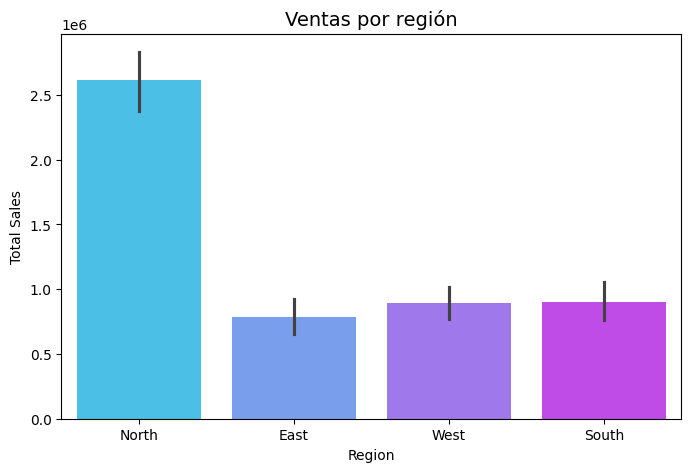

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x="Region",y="Total Sales",data=df_limpio, estimator=sum, palette="cool")
plt.title("Ventas por región", fontsize=14)
plt.xticks(rotation=0)

(array([19723., 19737., 19754., 19768., 19783., 19797., 19814., 19828.,
        19844.]),
 [Text(19723.0, 0, '2024-01-01'),
  Text(19737.0, 0, '2024-01-15'),
  Text(19754.0, 0, '2024-02-01'),
  Text(19768.0, 0, '2024-02-15'),
  Text(19783.0, 0, '2024-03-01'),
  Text(19797.0, 0, '2024-03-15'),
  Text(19814.0, 0, '2024-04-01'),
  Text(19828.0, 0, '2024-04-15'),
  Text(19844.0, 0, '2024-05-01')])

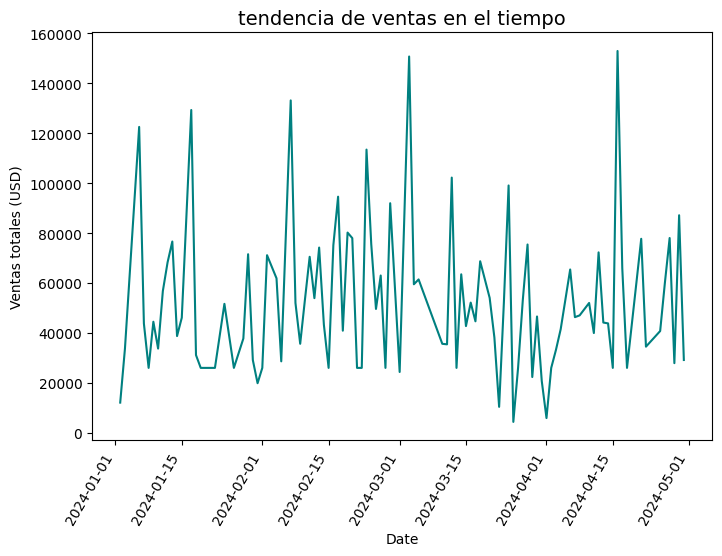

In [21]:
plt.figure(figsize=(8,6))
df_limpio.groupby("Date")["Total Sales"].sum().plot(kind="line",color="teal")
plt.title("tendencia de ventas en el tiempo", fontsize=14)
plt.ylabel("Ventas totales (USD)")
plt.xticks(rotation=60)

#tarea análisis por región


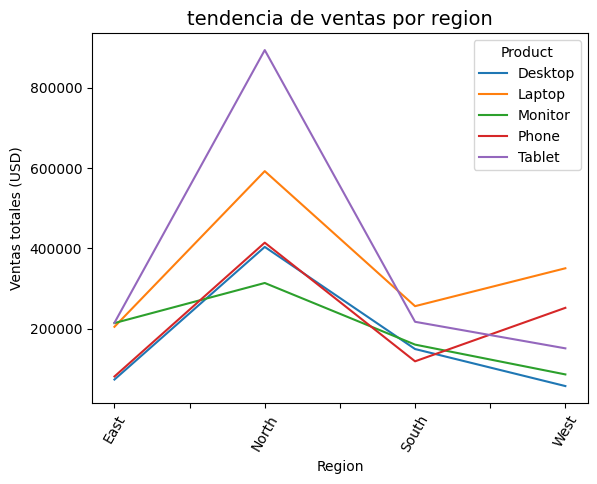

In [29]:
# Agrupamos por Región y Producto, y con unstack() ponemos las regiones en el eje X y cada producto como una línea
df_limpio.groupby(["Region", "Product"])["Total Sales"].sum().unstack().plot(kind="line")

plt.title("tendencia de ventas por region", fontsize=14)
plt.ylabel("Ventas totales (USD)")
plt.xticks(rotation=60)
plt.show()

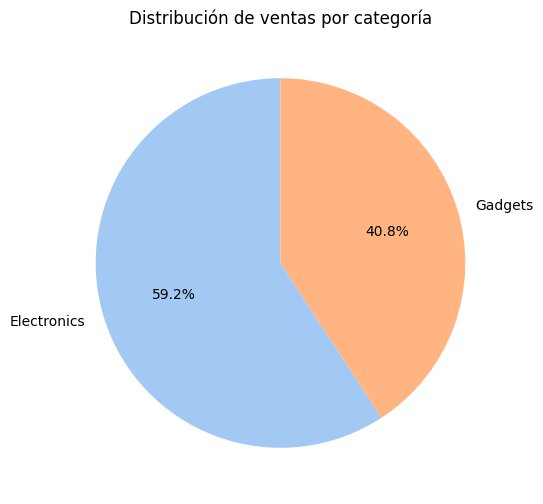

In [22]:
#ola torta
plt.figure(figsize=(6,6))
category_sales=df_limpio.groupby("Category")["Total Sales"].sum()
category_sales.plot(kind="pie",autopct="%1.1f%%",colors=sns.color_palette("pastel"), startangle=90)
plt.title("Distribución de ventas por categoría")
plt.ylabel("")
plt.show()

#Tarea2 unir pues las categorias
#Tarea3 realizar el análisis por producto y por región usando torta

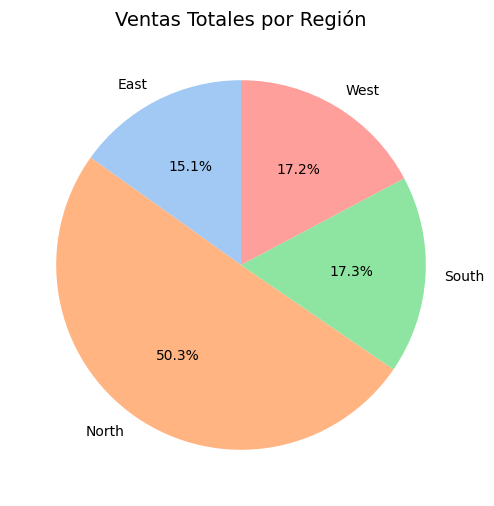

In [26]:
plt.figure(figsize=(6,6))
df.groupby("Region")["Total Sales"].sum().plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.title("Ventas Totales por Región", fontsize=14)
plt.ylabel("")
plt.show()

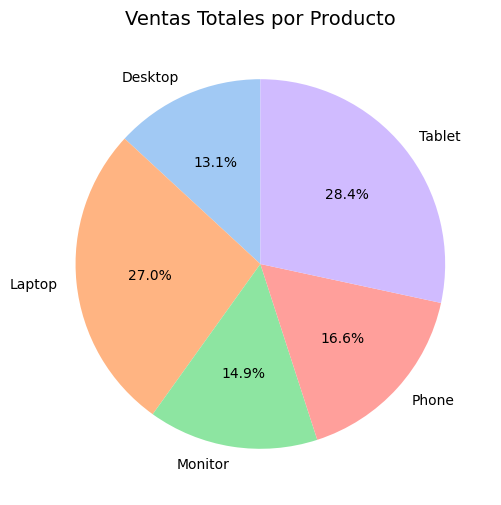

In [27]:
plt.figure(figsize=(6,6))
df.groupby("Product")["Total Sales"].sum().plot(
    kind="pie",
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("pastel")
)
plt.title("Ventas Totales por Producto", fontsize=14)
plt.ylabel("")
plt.show()